In [6]:
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
df=pd.read_csv("swiggy_vs_zomato_3000.csv")

In [8]:
df

,restaurant_id,restaurant_name,city,locality,restaurant_type,cuisines,distance_from_city_center_km,opening_time,closing_time,days_operational,...,swiggy_market_share_pct,zomato_market_share_pct,platform_performance_better,amenities,amenities_count,has_own_website,has_own_app,food_license_verified,listing_date,days_listed
0,REST000001,Restaurant_1,Mumbai,Mumbai_Locality_9,Cafe,Italian,4.1,12:00,22:00,601,...,50.0,50.0,Swiggy Better,Live Music; Family Friendly; Vegan Options; Wi...,6,False,False,True,2023-03-04,1168
1,REST000002,Restaurant_2,Mumbai,Mumbai_Locality_13,Casual Dining,Mughlai,1.9,09:00,23:00,3501,...,49.0,51.0,Swiggy Better,Dessert Bar; Live Music; Rooftop,3,False,True,True,2016-09-11,3533
2,REST000003,Restaurant_3,Mumbai,Mumbai_Locality_12,Fine Dine,Mediterranean,2.9,08:00,23:00,1485,...,42.0,58.0,Swiggy Better,Dessert Bar; Parking; Rooftop; Dine-in,4,True,True,False,2017-04-05,3327
3,REST000004,Restaurant_4,Mumbai,Mumbai_Locality_19,Cloud Kitchen,Desserts,13.2,08:00,23:00,1318,...,66.0,34.0,Zomato Better,Live Music; Outdoor Seating; Alcohol; Family F...,5,True,True,True,2024-07-28,656
4,REST000005,Restaurant_5,Mumbai,Mumbai_Locality_13,Cafe,Mexican,6.0,11:00,23:00,1947,...,52.0,48.0,Swiggy Better,Rooftop; Outdoor Seating; Alcohol; Takeaway; D...,7,True,True,True,2022-02-04,1561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,REST002496,Restaurant_2496,Lucknow,Lucknow_Locality_10,Food Truck,Pan-Asian,6.7,12:00,22:00,1503,...,48.0,52.0,Swiggy Better,Smoking Area; Family Friendly; Outdoor Seating...,6,False,True,True,2023-12-07,890
2496,REST002497,Restaurant_2497,Lucknow,Lucknow_Locality_14,Fine Dine,Vietnamese; Mediterranean,2.6,09:00,22:00,576,...,54.0,46.0,Zomato Better,Dessert Bar; WiFi; Alcohol; Parking,4,True,True,False,2020-09-26,2057
2497,REST002498,Restaurant_2498,Lucknow,Lucknow_Locality_16,Food Truck,Multi-Cuisine,3.5,09:00,22:00,247,...,62.0,38.0,Zomato Better,Smoking Area; Family Friendly; Outdoor Seating...,6,False,False,True,2016-05-29,3638
2498,REST002499,Restaurant_2499,Lucknow,Lucknow_Locality_9,Cafe,Korean; Korean,10.4,09:00,22:00,3066,...,58.0,42.0,Swiggy Better,Live Music; WiFi; Dine-in; AC; Outdoor Seating...,7,False,True,False,2021-11-04,1653


In [9]:
df.isnull().sum()

restaurant_id                           0
restaurant_name                         0
city                                    0
locality                                0
restaurant_type                         0
cuisines                                0
distance_from_city_center_km            0
opening_time                            0
closing_time                            0
days_operational                        0
swiggy_rating                           0
swiggy_total_reviews                    0
zomato_rating                           0
zomato_total_reviews                    0
average_rating_both_platforms           0
avg_cost_per_person_inr                 0
price_category                          0
swiggy_delivery_fee_inr                 0
zomato_delivery_fee_inr                 0
swiggy_avg_delivery_time_minutes        0
zomato_avg_delivery_time_minutes        0
swiggy_platform_commission_pct          0
zomato_platform_commission_pct          0
swiggy_discount_frequency_pct     

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.dtypes

restaurant_id                            object
restaurant_name                          object
city                                     object
locality                                 object
restaurant_type                          object
cuisines                                 object
distance_from_city_center_km            float64
opening_time                             object
closing_time                             object
days_operational                          int64
swiggy_rating                           float64
swiggy_total_reviews                      int64
zomato_rating                           float64
zomato_total_reviews                      int64
average_rating_both_platforms           float64
avg_cost_per_person_inr                   int64
price_category                           object
swiggy_delivery_fee_inr                   int64
zomato_delivery_fee_inr                   int64
swiggy_avg_delivery_time_minutes          int64
zomato_avg_delivery_time_minutes        

In [12]:
df.head(10)

,restaurant_id,restaurant_name,city,locality,restaurant_type,cuisines,distance_from_city_center_km,opening_time,closing_time,days_operational,...,swiggy_market_share_pct,zomato_market_share_pct,platform_performance_better,amenities,amenities_count,has_own_website,has_own_app,food_license_verified,listing_date,days_listed
0,REST000001,Restaurant_1,Mumbai,Mumbai_Locality_9,Cafe,Italian,4.1,12:00,22:00,601,...,50.0,50.0,Swiggy Better,Live Music; Family Friendly; Vegan Options; Wi...,6,False,False,True,2023-03-04,1168
1,REST000002,Restaurant_2,Mumbai,Mumbai_Locality_13,Casual Dining,Mughlai,1.9,09:00,23:00,3501,...,49.0,51.0,Swiggy Better,Dessert Bar; Live Music; Rooftop,3,False,True,True,2016-09-11,3533
2,REST000003,Restaurant_3,Mumbai,Mumbai_Locality_12,Fine Dine,Mediterranean,2.9,08:00,23:00,1485,...,42.0,58.0,Swiggy Better,Dessert Bar; Parking; Rooftop; Dine-in,4,True,True,False,2017-04-05,3327
3,REST000004,Restaurant_4,Mumbai,Mumbai_Locality_19,Cloud Kitchen,Desserts,13.2,08:00,23:00,1318,...,66.0,34.0,Zomato Better,Live Music; Outdoor Seating; Alcohol; Family F...,5,True,True,True,2024-07-28,656
4,REST000005,Restaurant_5,Mumbai,Mumbai_Locality_13,Cafe,Mexican,6.0,11:00,23:00,1947,...,52.0,48.0,Swiggy Better,Rooftop; Outdoor Seating; Alcohol; Takeaway; D...,7,True,True,True,2022-02-04,1561
5,REST000006,Restaurant_6,Mumbai,Mumbai_Locality_11,Food Truck,Thai; Vietnamese,7.6,09:00,23:00,488,...,65.0,35.0,Zomato Better,Alcohol; Private Room; Vegan Options; AC; Live...,5,True,False,False,2021-10-24,1664
6,REST000007,Restaurant_7,Mumbai,Mumbai_Locality_8,Cloud Kitchen,Thai,3.8,07:00,22:00,1414,...,56.0,44.0,Swiggy Better,Smoking Area; Vegan Options; Private Room; Fam...,8,True,True,False,2018-11-24,2729
7,REST000008,Restaurant_8,Mumbai,Mumbai_Locality_2,QSR (Quick Service),Mexican,10.3,07:00,22:00,2676,...,53.0,47.0,Zomato Better,Takeaway; Dine-in; Dessert Bar; Alcohol; Priva...,7,True,False,False,2020-11-03,2019
8,REST000009,Restaurant_9,Mumbai,Mumbai_Locality_13,Casual Dining,Mediterranean; Fast Food,0.5,09:00,23:00,1629,...,41.0,59.0,Zomato Better,Vegan Options; Family Friendly; Alcohol,3,True,True,True,2020-08-04,2110
9,REST000010,Restaurant_10,Mumbai,Mumbai_Locality_8,Casual Dining,Chinese,6.4,08:00,22:00,2363,...,50.0,50.0,Balanced,WiFi; Family Friendly; Parking; Takeaway; Dine...,8,True,False,False,2024-10-20,572


In [13]:
df.drop(columns=["restaurant_name"], inplace=True)

In [14]:
df.shape

(2500, 40)

In [15]:
df["opening_time"] = pd.to_datetime(df["opening_time"])

C:\Users\garry\AppData\Local\Temp\ipykernel_20092\3374857092.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["opening_time"] = pd.to_datetime(df["opening_time"])


In [16]:
df.dtypes

restaurant_id                                   object
city                                            object
locality                                        object
restaurant_type                                 object
cuisines                                        object
distance_from_city_center_km                   float64
opening_time                            datetime64[ns]
closing_time                                    object
days_operational                                 int64
swiggy_rating                                  float64
swiggy_total_reviews                             int64
zomato_rating                                  float64
zomato_total_reviews                             int64
average_rating_both_platforms                  float64
avg_cost_per_person_inr                          int64
price_category                                  object
swiggy_delivery_fee_inr                          int64
zomato_delivery_fee_inr                          int64
swiggy_avg

In [17]:
df["closing_time"]=pd.to_datetime(df["closing_time"])

C:\Users\garry\AppData\Local\Temp\ipykernel_20092\2231733910.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["closing_time"]=pd.to_datetime(df["closing_time"])


In [18]:
df["listing_date"]=pd.to_datetime(df["listing_date"])

In [19]:
df.dtypes

restaurant_id                                   object
city                                            object
locality                                        object
restaurant_type                                 object
cuisines                                        object
distance_from_city_center_km                   float64
opening_time                            datetime64[ns]
closing_time                            datetime64[ns]
days_operational                                 int64
swiggy_rating                                  float64
swiggy_total_reviews                             int64
zomato_rating                                  float64
zomato_total_reviews                             int64
average_rating_both_platforms                  float64
avg_cost_per_person_inr                          int64
price_category                                  object
swiggy_delivery_fee_inr                          int64
zomato_delivery_fee_inr                          int64
swiggy_avg

In [20]:
df1=df.groupby(df["restaurant_id"] == 101)["zomato_rating"].count().reset_index()

In [21]:
#Bar Chart

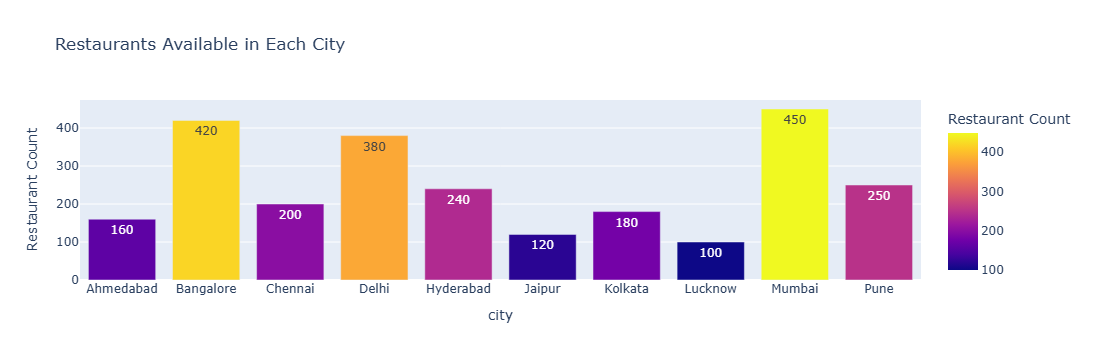

In [70]:
city_count = (
    df.groupby("city")
    .size()
    .reset_index(name="Restaurant Count")
)

fig1 = px.bar(
    city_count,
    x="city",
    y="Restaurant Count",
    color="Restaurant Count",
    text="Restaurant Count",
    title="Restaurants Available in Each City"
)

fig1.show()

In [69]:
#Line Chart

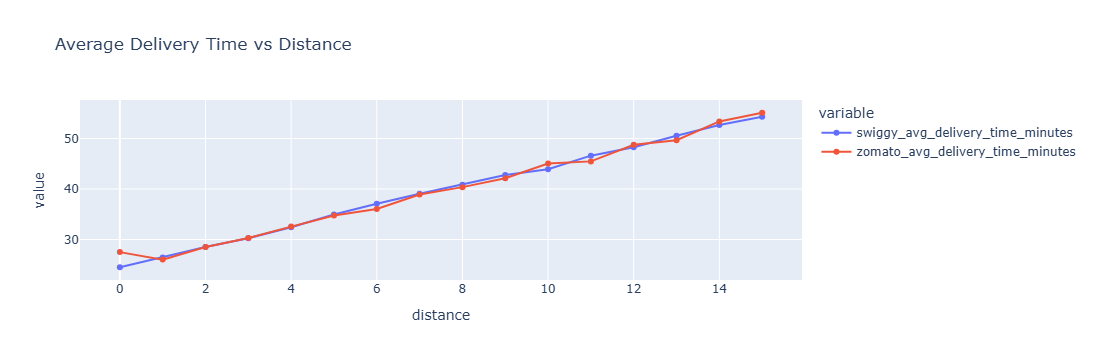

In [62]:
df["distance"] = df["distance_from_city_center_km"].round()

line_df = (
    df.groupby("distance")[[
        "swiggy_avg_delivery_time_minutes",
        "zomato_avg_delivery_time_minutes"
    ]]
    .mean()
    .reset_index()
)

fig2 = px.line(
    line_df,
    x="distance",
    y=[
        "swiggy_avg_delivery_time_minutes",
        "zomato_avg_delivery_time_minutes"
    ],
    markers=True,
    title="Average Delivery Time vs Distance"
)

fig2.show()

In [63]:
#Pie Chart

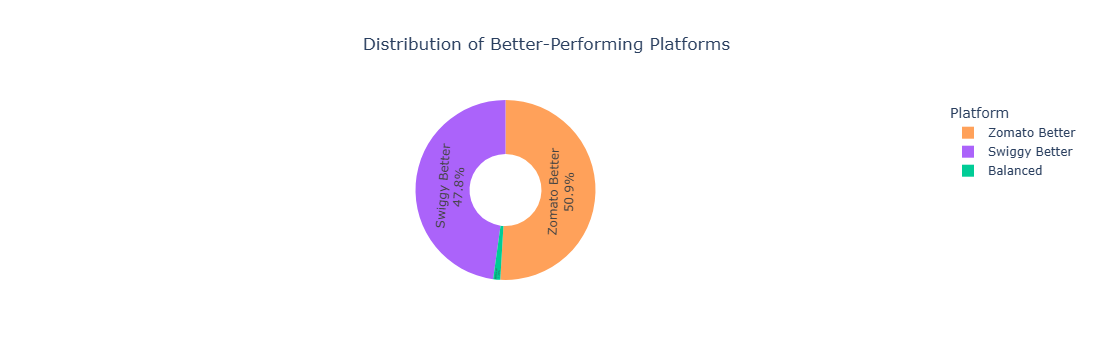

In [71]:
platform_share = (
    df.groupby("platform_performance_better")
    .size()
    .reset_index(name="Restaurant Count")
)

fig3 = px.pie(
    platform_share,
    names="platform_performance_better",
    values="Restaurant Count",
    title="Distribution of Better-Performing Platforms",
    hole=0.4,
    color="platform_performance_better",
    color_discrete_map={
        "Swiggy": "#FC8019",
        "Zomato": "#E23744"
    }
)

fig3.update_traces(
    textposition="inside",
    textinfo="percent+label"
)

fig3.update_layout(
    template="plotly_white",
    legend_title="Platform",
    title_x=0.5
)

fig3.show()

In [65]:
#Scatter Chart

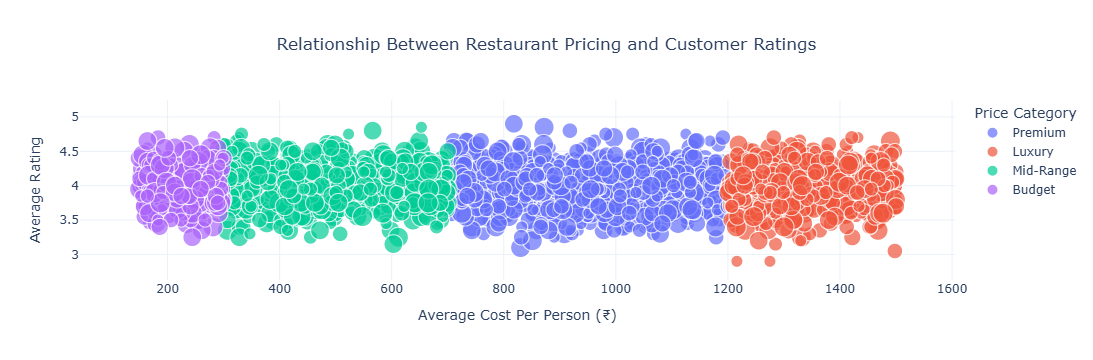

In [72]:
fig4 = px.scatter(
    df,
    x="avg_cost_per_person_inr",
    y="average_rating_both_platforms",
    color="price_category",
    size="amenities_count",
    title="Relationship Between Restaurant Pricing and Customer Ratings",
    labels={
        "avg_cost_per_person_inr": "Average Cost Per Person (₹)",
        "average_rating_both_platforms": "Average Rating",
        "price_category": "Price Category",
        "amenities_count": "Amenities Count"
    }
)

fig4.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Average Cost Per Person (₹)",
    yaxis_title="Average Rating",
    legend_title="Price Category"
)

fig4.show()

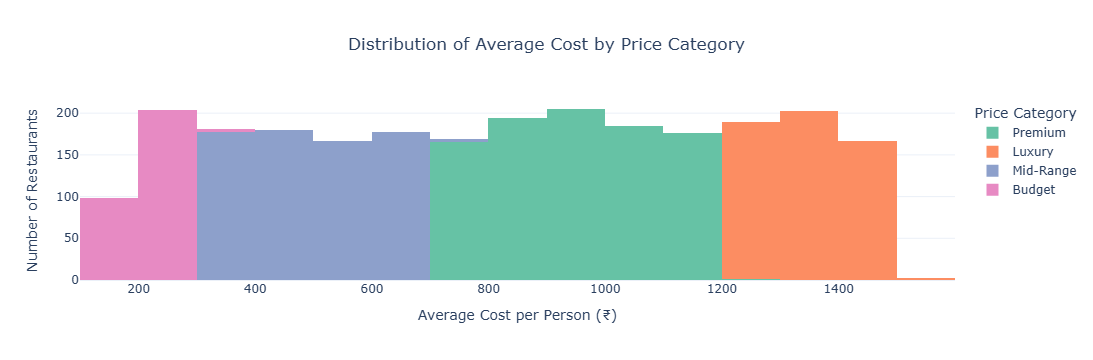

In [73]:
fig5 = px.histogram(
    df,
    x="avg_cost_per_person_inr",
    color="price_category",
    nbins=20,
    title="Distribution of Average Cost by Price Category",
    labels={
        "avg_cost_per_person_inr": "Average Cost per Person (₹)",
        "price_category": "Price Category"
    },
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig5.update_layout(
    template="plotly_white",
    xaxis_title="Average Cost per Person (₹)",
    yaxis_title="Number of Restaurants",
    legend_title="Price Category",
    title_x=0.5
)

fig5.show()

In [30]:
#Box Plot

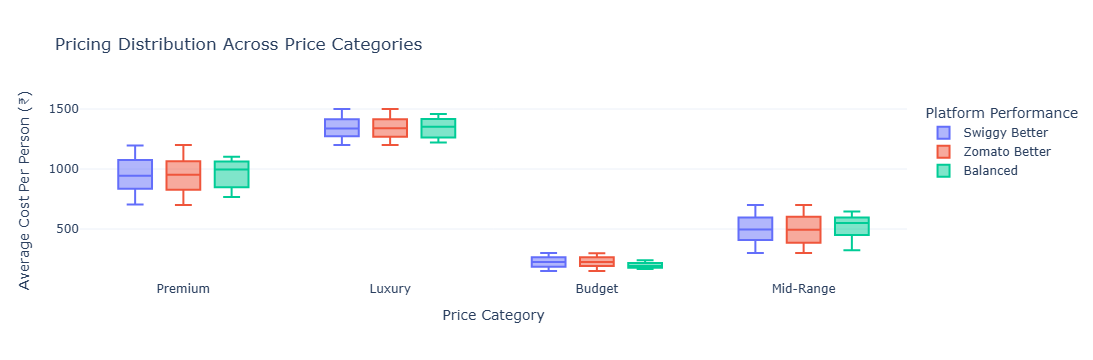

In [75]:
import plotly.express as px

fig6 = px.box(
    df,
    x="price_category",
    y="avg_cost_per_person_inr",
    color="platform_performance_better",
    points="outliers",
    title="Pricing Distribution Across Price Categories",
    labels={
        "price_category": "Price Category",
        "avg_cost_per_person_inr": "Average Cost Per Person (₹)",
        "platform_performance_better": "Better Performing Platform"
    }
)

fig6.update_layout(
    template="plotly_white",
    xaxis_title="Price Category",
    yaxis_title="Average Cost Per Person (₹)",
    legend_title="Platform Performance"
)

fig6.show()

In [77]:
#Violin Plot

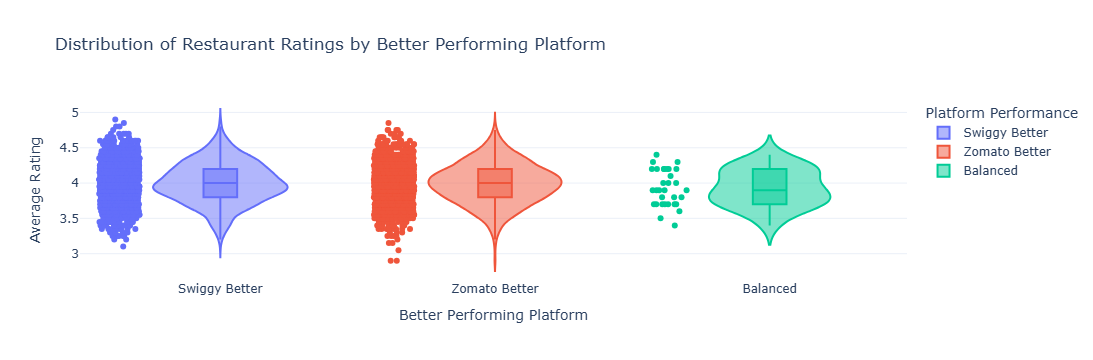

In [78]:
fig7 = px.violin(
    df,
    x="platform_performance_better",
    y="average_rating_both_platforms",
    color="platform_performance_better",
    box=True,
    points="all",
    title="Distribution of Restaurant Ratings by Better Performing Platform",
    labels={
        "platform_performance_better": "Better Performing Platform",
        "average_rating_both_platforms": "Average Rating"
    }
)

fig7.update_layout(
    template="plotly_white",
    xaxis_title="Better Performing Platform",
    yaxis_title="Average Rating",
    legend_title="Platform Performance"
)

fig7.show()

In [79]:
#Treemap

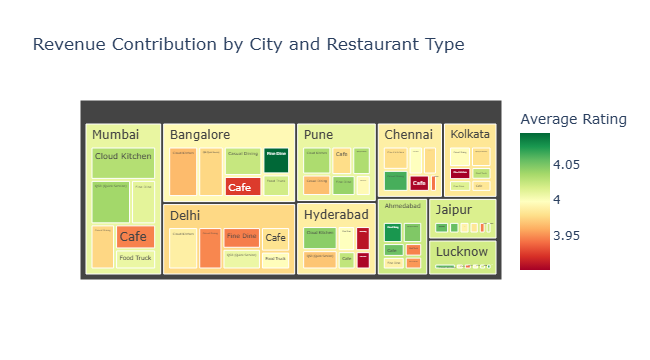

In [80]:
treemap_data = (
    df.groupby(["city", "restaurant_type"])
    .agg({
        "swiggy_estimated_monthly_revenue_inr": "sum",
        "average_rating_both_platforms": "mean"
    })
    .reset_index()
)

# Create treemap
fig8 = px.treemap(
    treemap_data,
    path=["city", "restaurant_type"],
    values="swiggy_estimated_monthly_revenue_inr",
    color="average_rating_both_platforms",
    color_continuous_scale="RdYlGn",
    title="Revenue Contribution by City and Restaurant Type",
    labels={
        "swiggy_estimated_monthly_revenue_inr": "Monthly Revenue (₹)",
        "average_rating_both_platforms": "Average Rating"
    }
)

fig8.update_layout(
    template="plotly_white"
)

fig8.show()

In [81]:
#Sunburst Chart

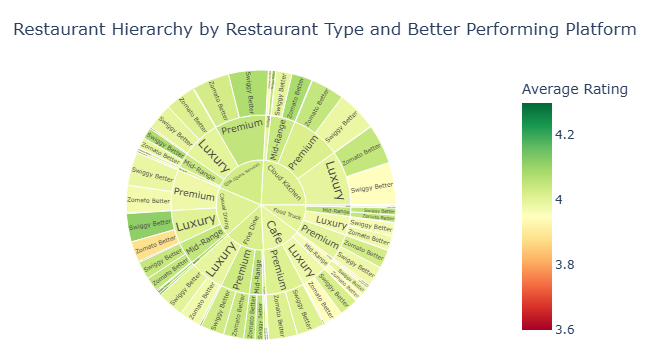

In [84]:
fig9 = px.sunburst(
    df,
    path=[
        "restaurant_type",
        "price_category",
        "platform_performance_better"
    ],
    values="swiggy_estimated_monthly_revenue_inr",
    color="average_rating_both_platforms",
    color_continuous_scale="RdYlGn",
    title="Restaurant Hierarchy by Restaurant Type and Better Performing Platform",
    labels={
        "restaurant_type": "Restaurant Type",
        "price_category": "Price Category",
        "platform_performance_better": "Better Platform",
        "swiggy_estimated_monthly_revenue_inr": "Monthly Revenue (₹)",
        "average_rating_both_platforms": "Average Rating"
    },
    hover_data={
        "average_rating_both_platforms": ":.2f"
    }
)

fig9.update_layout(
    template="plotly_white",
    title_x=0.5,
    margin=dict(t=70, l=20, r=20, b=20)
)

fig9.show()

In [85]:
#Bubble chart

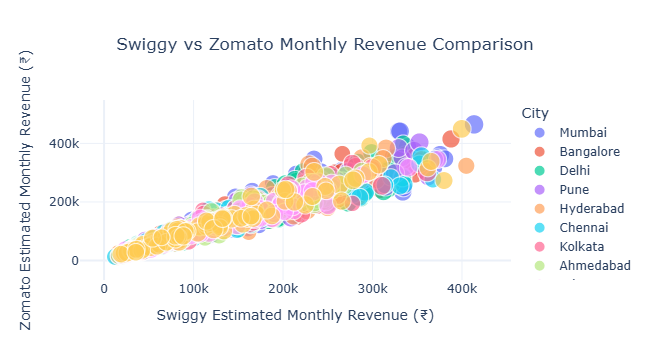

In [86]:
fig10 = px.scatter(
    df,
    x="swiggy_estimated_monthly_revenue_inr",
    y="zomato_estimated_monthly_revenue_inr",
    size="average_rating_both_platforms",
    color="city",
    hover_data={
        "restaurant_type": True,
        "price_category": True,
        "average_rating_both_platforms": ":.2f",
        "swiggy_estimated_monthly_revenue_inr": ":,.0f",
        "zomato_estimated_monthly_revenue_inr": ":,.0f"
    },
    title="Swiggy vs Zomato Monthly Revenue Comparison",
    labels={
        "swiggy_estimated_monthly_revenue_inr": "Swiggy Monthly Revenue (₹)",
        "zomato_estimated_monthly_revenue_inr": "Zomato Monthly Revenue (₹)",
        "average_rating_both_platforms": "Average Rating",
        "city": "City"
    }
)

fig10.update_layout(
    template="plotly_white",
    title_x=0.5,
    xaxis_title="Swiggy Estimated Monthly Revenue (₹)",
    yaxis_title="Zomato Estimated Monthly Revenue (₹)",
    legend_title="City"
)

fig10.show() 

In [88]:
#Density Heatmap

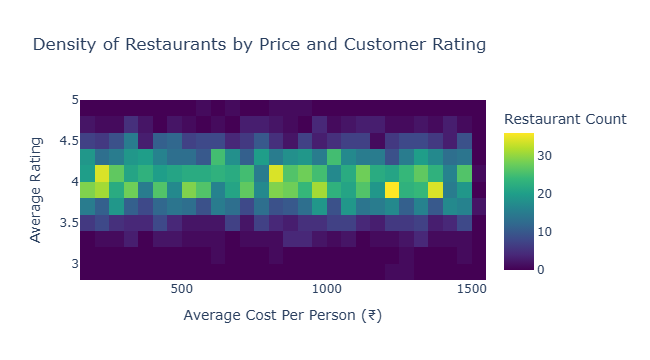

In [87]:
fig11 = px.density_heatmap(
    df,
    x="avg_cost_per_person_inr",
    y="average_rating_both_platforms",
    nbinsx=30,
    nbinsy=20,
    color_continuous_scale="Viridis",
    title="Density of Restaurants by Price and Customer Rating",
    labels={
        "avg_cost_per_person_inr": "Average Cost Per Person (₹)",
        "average_rating_both_platforms": "Average Rating"
    }
)

fig11.update_layout(
    template="plotly_white",
    xaxis_title="Average Cost Per Person (₹)",
    yaxis_title="Average Rating",
    coloraxis_colorbar_title="Restaurant Count"
)

fig11.show()

In [89]:
#Funnel chart

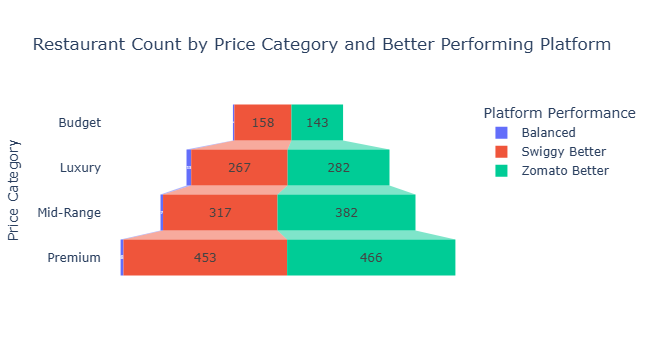

In [90]:
funnel_data = (
    df.groupby(["price_category", "platform_performance_better"])
    .size()
    .reset_index(name="Restaurant Count")
)

# Create Funnel Chart
fig12 = px.funnel(
    funnel_data,
    y="price_category",
    x="Restaurant Count",
    color="platform_performance_better",
    title="Restaurant Count by Price Category and Better Performing Platform",
    labels={
        "price_category": "Price Category",
        "Restaurant Count": "Number of Restaurants",
        "platform_performance_better": "Better Performing Platform"
    }
)

fig12.update_layout(
    template="plotly_white",
    legend_title="Platform Performance"
)

fig12.show()

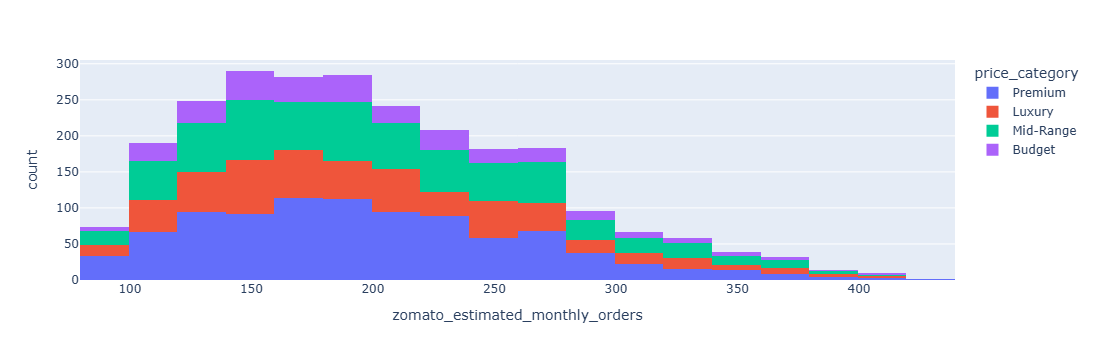

In [47]:
fig11=px.histogram(
    df,
    x="zomato_estimated_monthly_orders",
color="price_category",
nbins=20)
fig11.show()

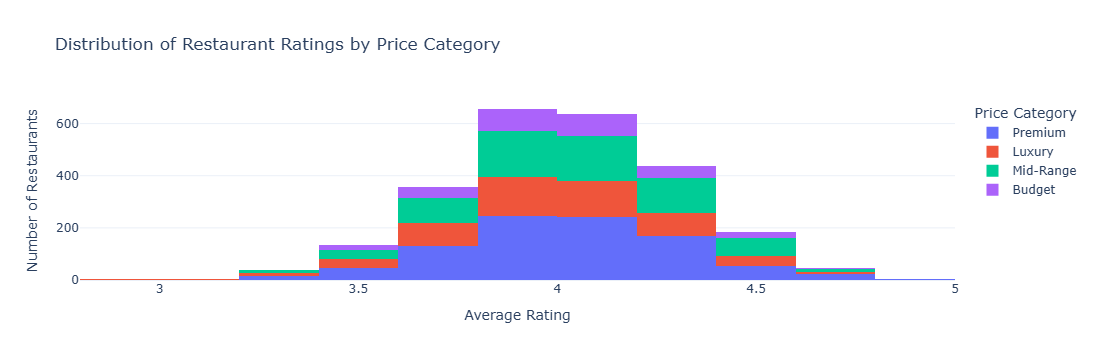

In [48]:
# Create histogram
fig = px.histogram(
    df,
    x='average_rating_both_platforms',
    color='price_category',
    nbins=20,  # Adjust the number of bins if needed
    title='Distribution of Restaurant Ratings by Price Category',
    labels={
        'average_rating_both_platforms': 'Average Rating',
        'price_category': 'Price Category'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Average Rating',
    yaxis_title='Number of Restaurants',
    legend_title='Price Category'
)

fig.show()

In [49]:
#density heatmap

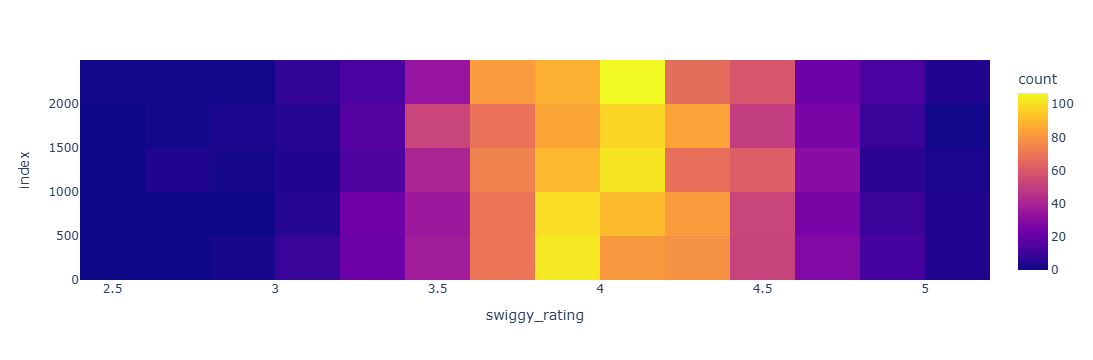

In [50]:
fig12=px.density_heatmap(df,
                         x="swiggy_rating",
                        )
fig12.show()

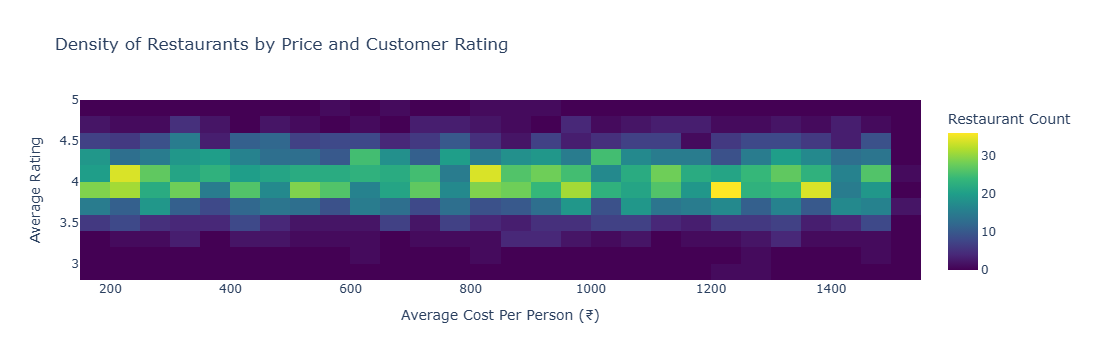

In [51]:
import plotly.express as px

# Create Density Heatmap
fig = px.density_heatmap(
    df,
    x='avg_cost_per_person_inr',
    y='average_rating_both_platforms',
    nbinsx=30,
    nbinsy=20,
    color_continuous_scale='Viridis',
    title='Density of Restaurants by Price and Customer Rating',
    labels={
        'avg_cost_per_person_inr': 'Average Cost Per Person (₹)',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white',
    xaxis_title='Average Cost Per Person (₹)',
    yaxis_title='Average Rating',
    coloraxis_colorbar_title='Restaurant Count'
)

fig.show()

In [52]:
#tree map chart

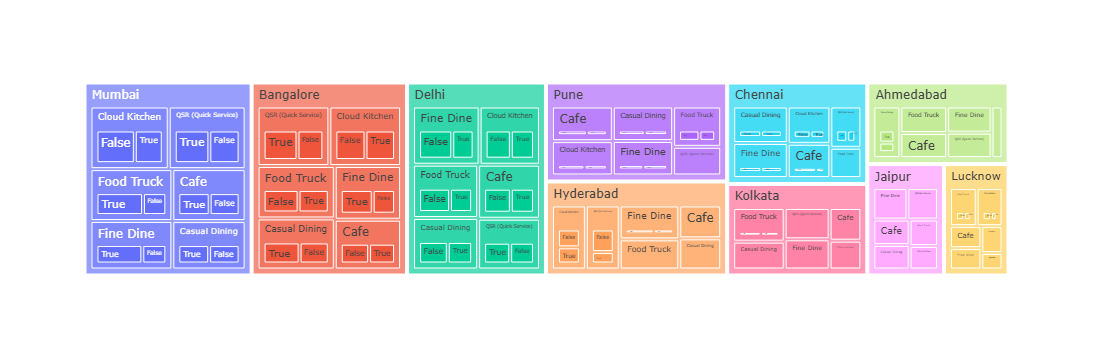

In [53]:
fig13=px.treemap(
    df,
    path=["city","restaurant_type","has_own_website"],
    values="zomato_rating")
fig13.show()

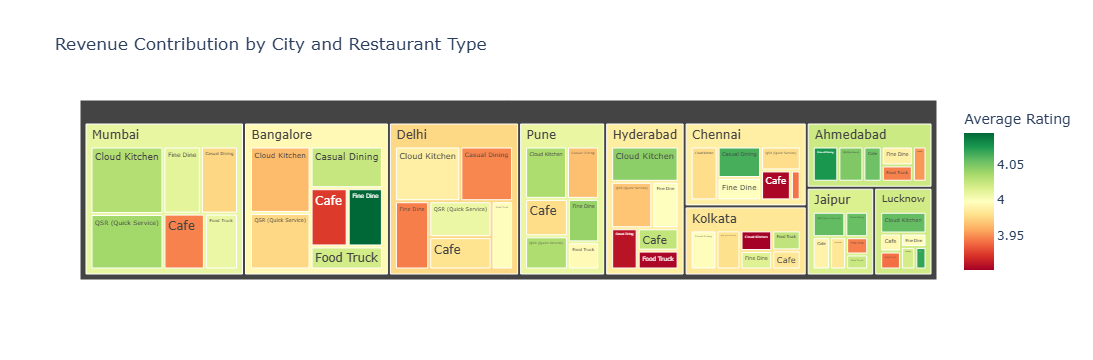

In [54]:
# Group the data
treemap_data = (
    df.groupby(['city', 'restaurant_type'])
      .agg({
          'swiggy_estimated_monthly_revenue_inr': 'sum',
          'average_rating_both_platforms': 'mean'
      })
      .reset_index()
)

# Create treemap
fig = px.treemap(
    treemap_data,
    path=['city', 'restaurant_type'],
    values='swiggy_estimated_monthly_revenue_inr',
    color='average_rating_both_platforms',
    color_continuous_scale='RdYlGn',
    title='Revenue Contribution by City and Restaurant Type',
    labels={
        'swiggy_estimated_monthly_revenue_inr': 'Monthly Revenue (₹)',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

In [55]:
#sunburst chart

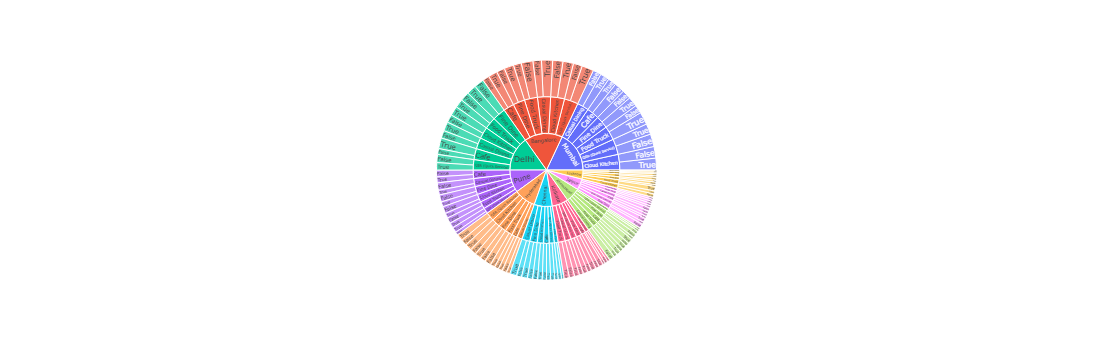

In [56]:
fig14=px.sunburst(df,
                  path=["city","restaurant_type","has_own_app"],
                  values="swiggy_rating")
fig14.show()

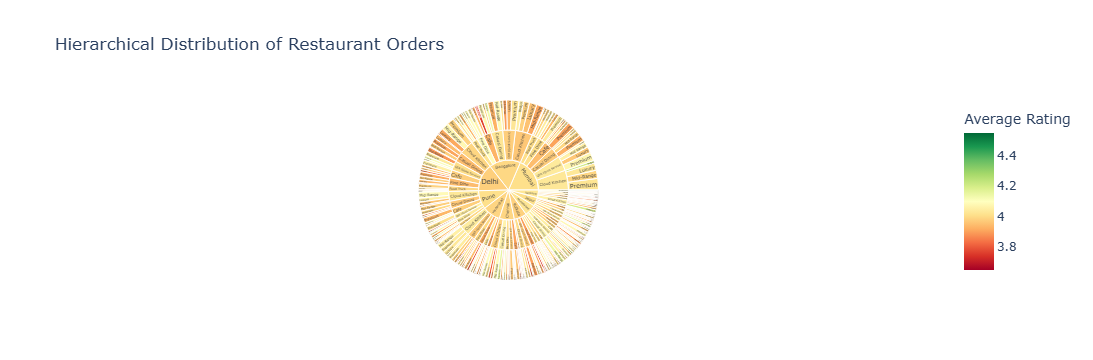

In [57]:
import pandas as pd
import plotly.express as px

# Group the data
sunburst_data = (
    df.groupby(['city', 'restaurant_type', 'price_category'])
      .agg({
          'zomato_estimated_monthly_orders': 'sum',
          'average_rating_both_platforms': 'mean'
      })
      .reset_index()
)

# Create Sunburst Chart
fig = px.sunburst(
    sunburst_data,
    path=['city', 'restaurant_type', 'price_category'],
    values='zomato_estimated_monthly_orders',
    color='average_rating_both_platforms',
    color_continuous_scale='RdYlGn',
    title='Hierarchical Distribution of Restaurant Orders',
    labels={
        'zomato_estimated_monthly_orders': 'Monthly Orders',
        'average_rating_both_platforms': 'Average Rating'
    }
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

In [58]:
#funnel chart

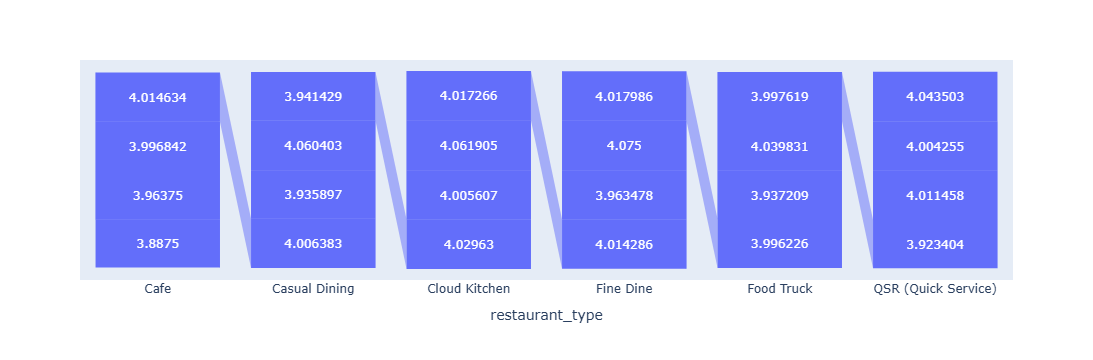

In [59]:
fig15=px.funnel(df1,
            x="restaurant_type",
            y="zomato_rating"            
)
fig15.show()

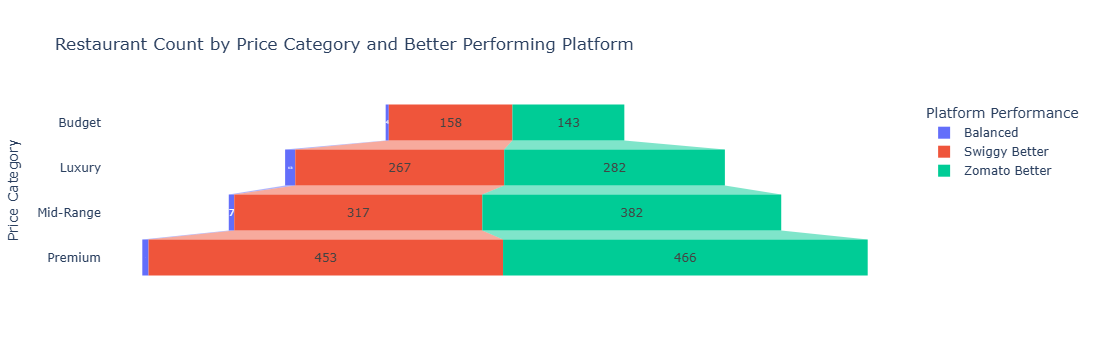

In [60]:
import pandas as pd
import plotly.express as px

# Group the data
funnel_data = (
    df.groupby(['price_category', 'platform_performance_better'])
      .size()
      .reset_index(name='Restaurant Count')
)

# Create Funnel Chart
fig = px.funnel(
    funnel_data,
    y='price_category',
    x='Restaurant Count',
    color='platform_performance_better',
    title='Restaurant Count by Price Category and Better Performing Platform',
    labels={
        'price_category': 'Price Category',
        'Restaurant Count': 'Number of Restaurants',
        'platform_performance_better': 'Better Performing Platform'
    }
)

fig.update_layout(
    template='plotly_white',
    legend_title='Platform Performance'
)

fig.show()